# NumPy 응용 - 실전 활용

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 1. 선형대수 연산 (Linear Algebra)

## 행렬 연산

In [2]:
# 행렬 곱셈
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# @ 연산자 또는 np.dot() 사용
result = A @ B  # 행렬 곱셈
print('A:')
print(A)
print('\nB:')
print(B)
print('\nA @ B:')
print(result)

A:
[[1 2]
 [3 4]]

B:
[[5 6]
 [7 8]]

A @ B:
[[19 22]
 [43 50]]


In [3]:
# 전치 행렬
A_transpose = A.T
print('A 전치행렬:')
print(A_transpose)

A 전치행렬:
[[1 3]
 [2 4]]


In [4]:
# 행렬식 (Determinant)
det_A = np.linalg.det(A)
print(f'A의 행렬식: {det_A}')

A의 행렬식: -2.0000000000000004


In [5]:
# 역행렬
A_inv = np.linalg.inv(A)
print('A의 역행렬:')
print(A_inv)

# 검증: A * A^-1 = I (단위행렬)
print('\n검증 (A * A^-1):')
print(A @ A_inv)

A의 역행렬:
[[-2.   1. ]
 [ 1.5 -0.5]]

검증 (A * A^-1):
[[1.00000000e+00 1.11022302e-16]
 [0.00000000e+00 1.00000000e+00]]


In [6]:
# 고유값과 고유벡터
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f'고유값: {eigenvalues}')
print('\n고유벡터:')
print(eigenvectors)

고유값: [-0.37228132  5.37228132]

고유벡터:
[[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


## 연립방정식 풀이

In [7]:
# 2x + 3y = 8
# x - y = 1
# 을 풀기

# 계수 행렬
A = np.array([[2, 3], [1, -1]])
# 상수항 벡터
b = np.array([8, 1])

# np.linalg.solve(A, b)
solution = np.linalg.solve(A, b)
print(f'x = {solution[0]}, y = {solution[1]}')

# 검증
print(f'\n검증:')
print(f'2*{solution[0]} + 3*{solution[1]} = {2*solution[0] + 3*solution[1]}')
print(f'{solution[0]} - {solution[1]} = {solution[0] - solution[1]}')

x = 2.2, y = 1.2

검증:
2*2.2 + 3*1.2 = 8.0
2.2 - 1.2 = 1.0000000000000002


# 2. 통계 분석

In [8]:
# 정규분포 데이터 생성
data = np.random.normal(loc=100, scale=15, size=1000)

print(f'평균: {np.mean(data):.2f}')
print(f'중앙값: {np.median(data):.2f}')
print(f'표준편차: {np.std(data):.2f}')
print(f'분산: {np.var(data):.2f}')
print(f'최소값: {np.min(data):.2f}')
print(f'최대값: {np.max(data):.2f}')
print(f'사분위수: {np.percentile(data, [25, 50, 75])}')

평균: 100.76
중앙값: 99.97
표준편차: 14.42
분산: 207.82
최소값: 60.43
최대값: 148.24
사분위수: [ 90.72812845  99.97475194 110.10648489]


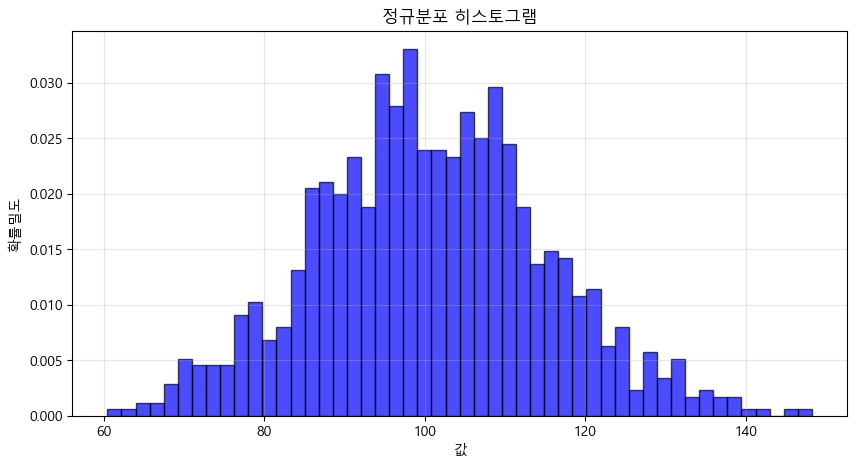

In [9]:
# 정규분포 시각화
plt.figure(figsize=(10, 5))
plt.hist(data, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('값')
plt.ylabel('확률밀도')
plt.title('정규분포 히스토그램')
plt.grid(alpha=0.3)
plt.savefig('results/numpy_13_7.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. 신호 처리 (Signal Processing)

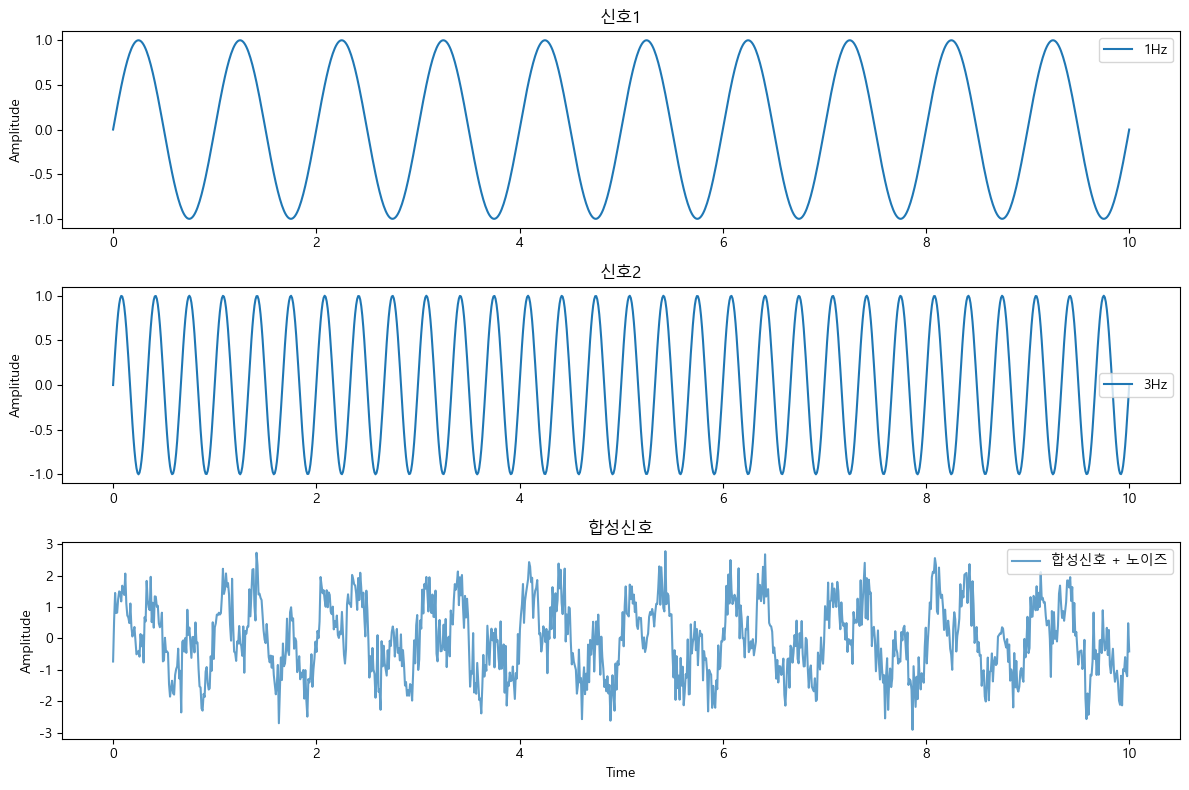

In [10]:
# 복합 신호 생성
t = np.linspace(0, 10, 1000)
signal1 = np.sin(2 * np.pi * 1 * t)  # 1Hz
signal2 = np.sin(2 * np.pi * 3 * t)  # 3Hz
noise = 0.5 * np.random.randn(len(t))

# 신호 합치기
combined_signal = signal1 + signal2 + noise

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, signal1, label='1Hz')
plt.ylabel('Amplitude')
plt.title('신호1')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t, signal2, label='3Hz')
plt.ylabel('Amplitude')
plt.title('신호2')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t, combined_signal, alpha=0.7, label='합성신호 + 노이즈')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.title('합성신호')
plt.legend()
plt.tight_layout()
plt.savefig('results/numpy_15_29.png', dpi=300, bbox_inches='tight')
plt.show()

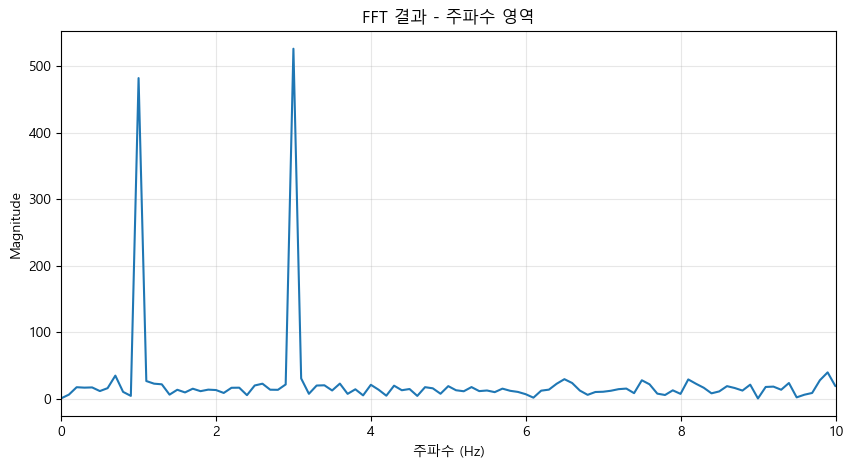

In [11]:
# FFT (Fast Fourier Transform) - 주파수 영역 분석
fft_result = np.fft.fft(combined_signal)
frequencies = np.fft.fftfreq(len(t), t[1] - t[0])
magnitude = np.abs(fft_result)

plt.figure(figsize=(10, 5))
plt.plot(frequencies[:len(frequencies)//2], magnitude[:len(magnitude)//2])
plt.xlabel('주파수 (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT 결과 - 주파수 영역')
plt.xlim(0, 10)
plt.grid(alpha=0.3)
plt.savefig('results/numpy_16_12.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 이미지 처리 기초

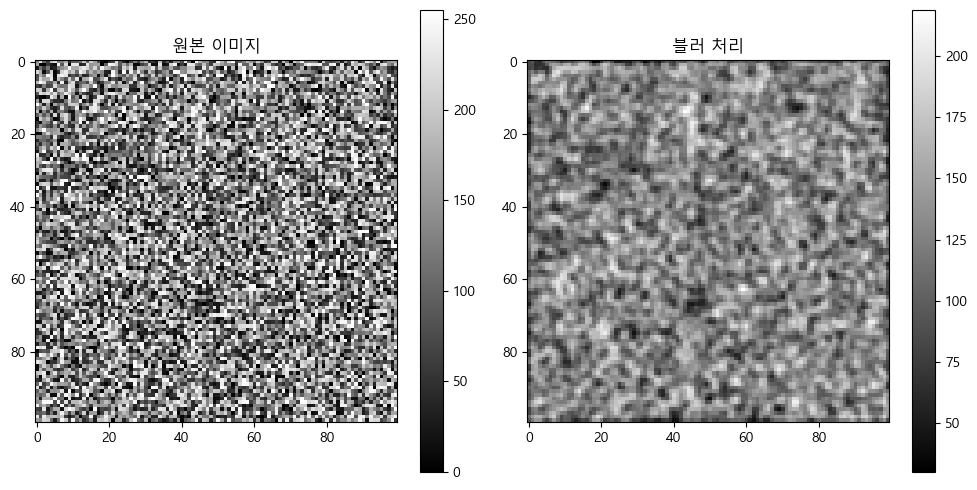

In [12]:
# 그레이스케일 이미지 시뮬레이션
image = np.random.randint(0, 256, (100, 100))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('원본 이미지')
plt.colorbar()

# 가우시안 블러 효과 (간단한 필터)
kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
from scipy import signal
blurred = signal.convolve2d(image, kernel, mode='same')

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title('블러 처리')
plt.colorbar()
plt.tight_layout()
plt.savefig('results/numpy_18_19.png', dpi=300, bbox_inches='tight')
plt.show()

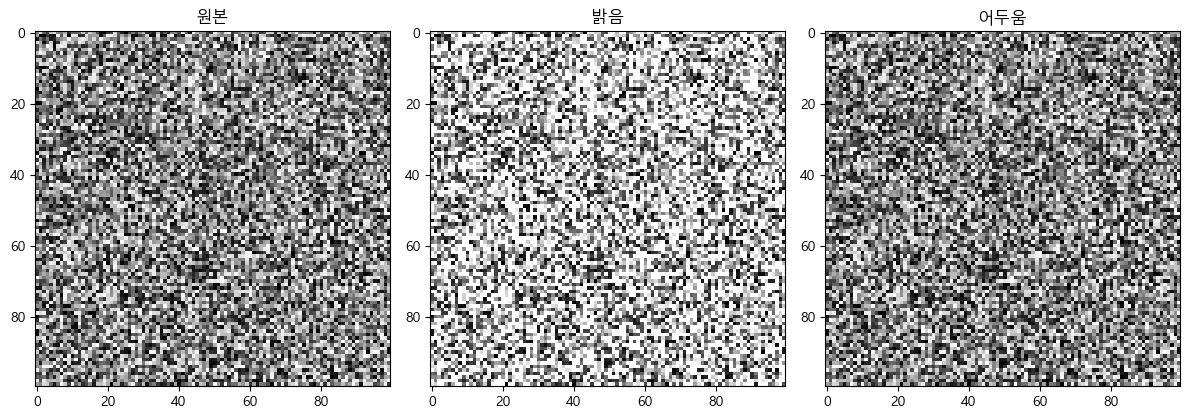

In [13]:
# 이미지 브라이트니스 조정
brightened = np.clip(image * 1.5, 0, 255).astype(int)
darkened = np.clip(image * 0.5, 0, 255).astype(int)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('원본')

plt.subplot(1, 3, 2)
plt.imshow(brightened, cmap='gray')
plt.title('밝음')

plt.subplot(1, 3, 3)
plt.imshow(darkened, cmap='gray')
plt.title('어두움')
plt.tight_layout()
plt.savefig('results/numpy_19_17.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. 확률 분포 생성 및 분석

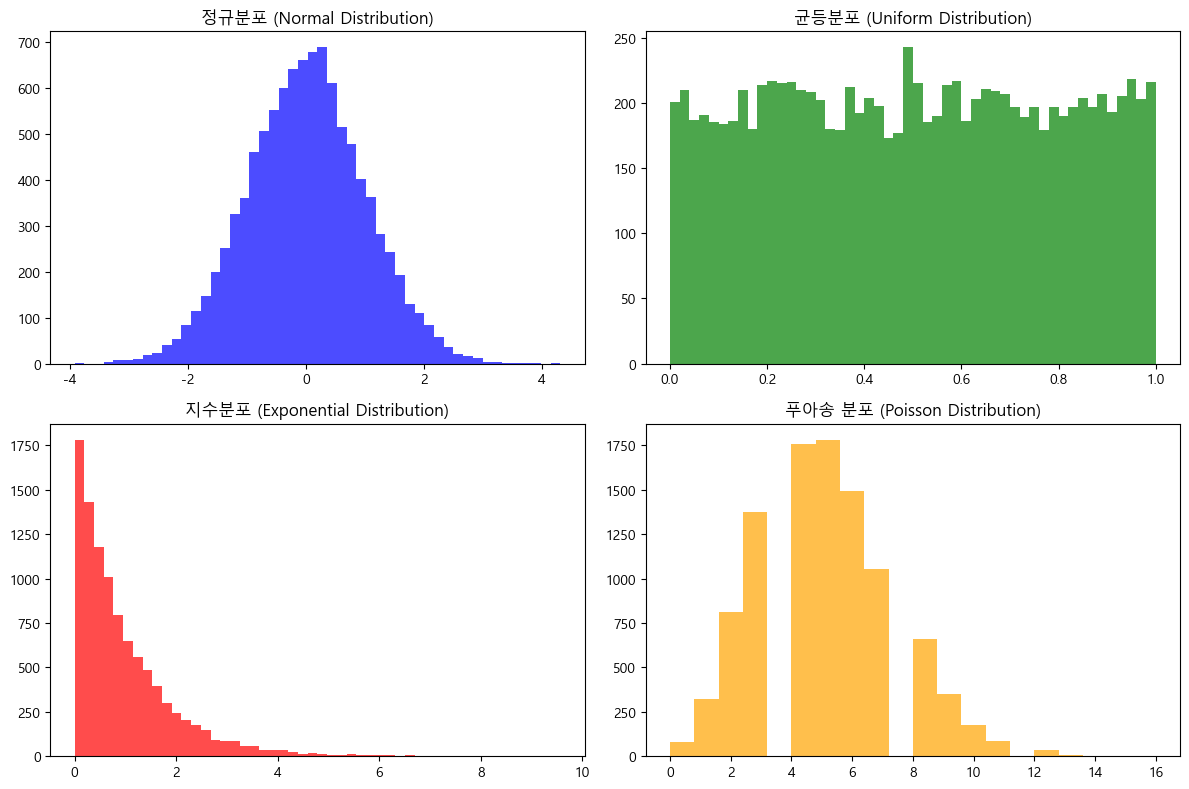

In [14]:
# 다양한 분포 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 정규분포
normal_data = np.random.normal(0, 1, 10000)
axes[0, 0].hist(normal_data, bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('정규분포 (Normal Distribution)')

# 균등분포
uniform_data = np.random.uniform(0, 1, 10000)
axes[0, 1].hist(uniform_data, bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('균등분포 (Uniform Distribution)')

# 지수분포
exponential_data = np.random.exponential(1, 10000)
axes[1, 0].hist(exponential_data, bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('지수분포 (Exponential Distribution)')

# 푸아송 분포
poisson_data = np.random.poisson(5, 10000)
axes[1, 1].hist(poisson_data, bins=20, alpha=0.7, color='orange')
axes[1, 1].set_title('푸아송 분포 (Poisson Distribution)')

plt.tight_layout()
plt.show()

# 6. 시뮬레이션 (Monte Carlo)

In [15]:
# 원의 넓이 추정 (Monte Carlo)
num_samples = 100000

# 0~1 범위의 랜덤 좌표
x = np.random.uniform(0, 1, num_samples)
y = np.random.uniform(0, 1, num_samples)

# 원점으로부터의 거리
distances = np.sqrt(x**2 + y**2)

# 원 내부의 점 개수
inside_circle = np.sum(distances <= 1)

# 파이 값 추정
pi_estimate = 4 * inside_circle / num_samples
print(f'추정된 파이 값: {pi_estimate:.4f}')
print(f'실제 파이 값: {np.pi:.4f}')
print(f'오차: {abs(pi_estimate - np.pi):.4f}')

추정된 파이 값: 3.1423
실제 파이 값: 3.1416
오차: 0.0007


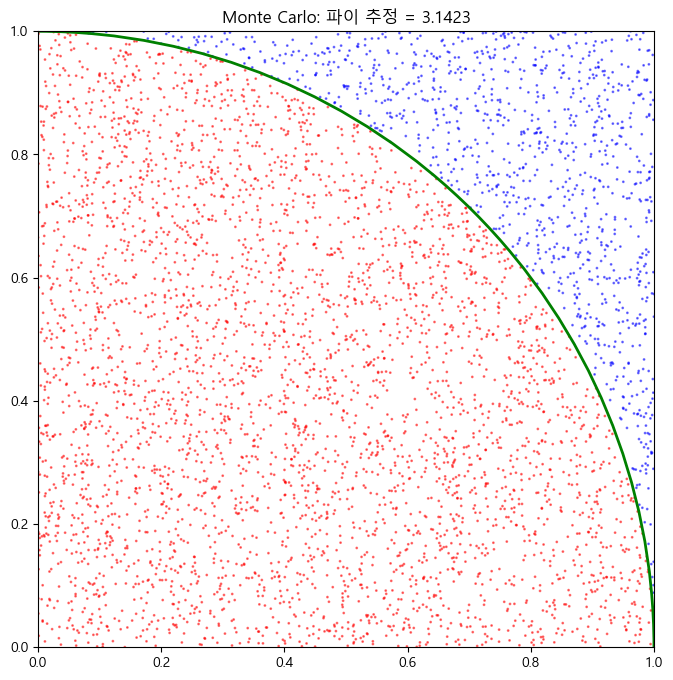

In [16]:
# 시각화
plt.figure(figsize=(8, 8))
colors = ['red' if d <= 1 else 'blue' for d in distances[:5000]]
plt.scatter(x[:5000], y[:5000], c=colors, s=1, alpha=0.5)
circle = plt.Circle((0, 0), 1, fill=False, color='green', linewidth=2)
plt.gca().add_patch(circle)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.title(f'Monte Carlo: 파이 추정 = {pi_estimate:.4f}')
plt.savefig('results/numpy_24_10.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. 최적화 (Optimization)

최적값: x = 1.1900, f(x) = 3.6561
실제 최적값: x = 2, f(x) = 3


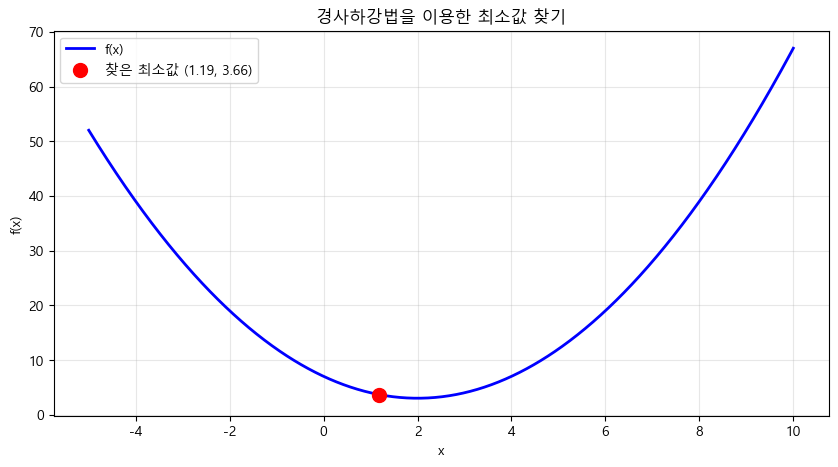

In [17]:
# 함수의 최소값 찾기
# f(x) = (x-2)^2 + 3 의 최소값 찾기

def f(x):
    return (x - 2)**2 + 3

x_values = np.linspace(-5, 10, 1000)
y_values = f(x_values)

# 경사하강법 구현
x = np.random.uniform(-5, 10)  # 시작점
learning_rate = 0.01
for i in range(100):
    gradient = 2 * (x - 2)  # 미분
    x = x - learning_rate * gradient

print(f'최적값: x = {x:.4f}, f(x) = {f(x):.4f}')
print(f'실제 최적값: x = 2, f(x) = 3')

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, 'b-', linewidth=2, label='f(x)')
plt.plot(x, f(x), 'ro', markersize=10, label=f'찾은 최소값 ({x:.2f}, {f(x):.2f})')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('경사하강법을 이용한 최소값 찾기')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('results/numpy_26_28.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. 데이터 정규화 (Normalization)

Min-Max 정규화:
[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.47368421
 1.        ]

Z-Score 정규화:
[-0.8811039  -0.71879529 -0.55648667 -0.39417806 -0.23186945  0.57967362
  2.20275975]


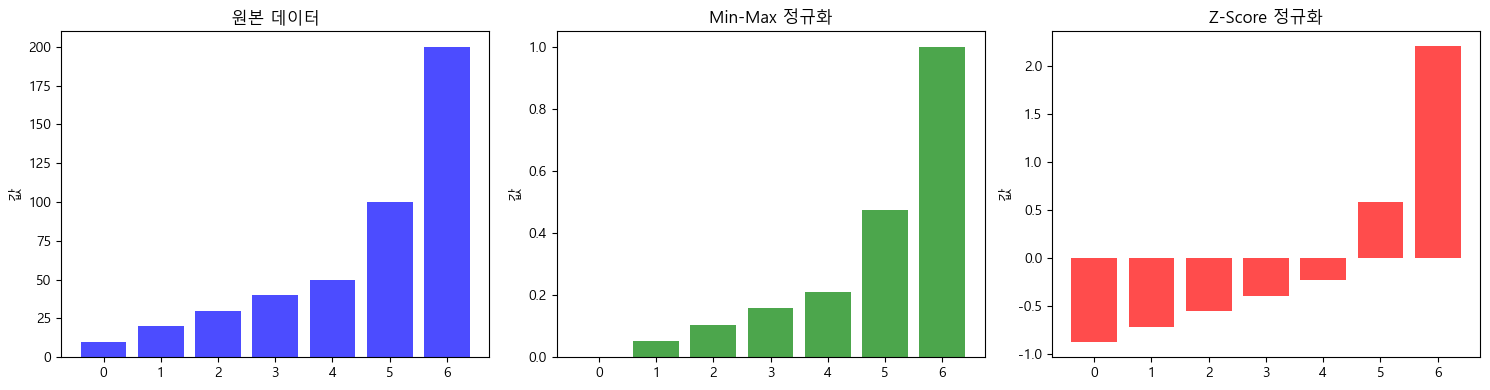

In [18]:
# 샘플 데이터
data = np.array([10, 20, 30, 40, 50, 100, 200])

# Min-Max 정규화
normalized_minmax = (data - np.min(data)) / (np.max(data) - np.min(data))
print('Min-Max 정규화:')
print(normalized_minmax)

# Z-Score 정규화 (표준화)
normalized_zscore = (data - np.mean(data)) / np.std(data)
print('\nZ-Score 정규화:')
print(normalized_zscore)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(len(data)), data, color='blue', alpha=0.7)
axes[0].set_title('원본 데이터')
axes[0].set_ylabel('값')

axes[1].bar(range(len(normalized_minmax)), normalized_minmax, color='green', alpha=0.7)
axes[1].set_title('Min-Max 정규화')
axes[1].set_ylabel('값')

axes[2].bar(range(len(normalized_zscore)), normalized_zscore, color='red', alpha=0.7)
axes[2].set_title('Z-Score 정규화')
axes[2].set_ylabel('값')

plt.tight_layout()
plt.show()

# 9. 배열 연산 최적화

In [19]:
# Vectorization의 중요성
import time

n = 1000000
a = np.random.randn(n)
b = np.random.randn(n)

# 루프 방식 (느림)
start = time.time()
result_loop = 0
for i in range(n):
    result_loop += a[i] * b[i]
loop_time = time.time() - start

# NumPy 벡터 연산 (빠름)
start = time.time()
result_numpy = np.dot(a, b)
numpy_time = time.time() - start

print(f'루프 방식 시간: {loop_time:.4f}초')
print(f'NumPy 벡터 연산 시간: {numpy_time:.4f}초')
print(f'속도 향상: {loop_time/numpy_time:.1f}배')

루프 방식 시간: 0.3100초
NumPy 벡터 연산 시간: 0.0030초
속도 향상: 102.2배
